<a href="https://colab.research.google.com/github/darshanananth/Symbol_detection/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
!pip install torch torchvision timm opencv-python pillow matplotlib numpy

In [30]:
import cv2
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load pretrained DINO ViT
model = timm.create_model(
    "vit_small_patch16_224.dino",
    pretrained=True
)
model.eval()
model.to(device)
model.reset_classifier(0)

In [32]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [33]:
# Path examples (change as needed)
PID_PATH = "/content/pid_diagram.png"
LEGEND_SYMBOL_PATH = "/content/legend_valve.jpg"

# Load color image (keep color!)
pid_bgr = cv2.imread(PID_PATH)
assert pid_bgr is not None, "Image not loaded"

pid_rgb = cv2.cvtColor(pid_bgr, cv2.COLOR_BGR2RGB)

# ✅ REPLACEMENT FOR GRAYSCALE
# Edge-preserving grayscale for P&ID
pid_gray = np.max(pid_rgb, axis=2).astype(np.uint8)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


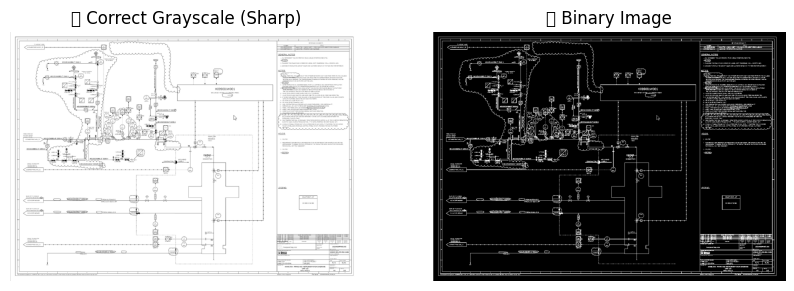

In [41]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(pid_gray, cmap="gray")
plt.title("✅ Correct Grayscale (Sharp)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(bw, cmap="gray")
plt.title("✅ Binary Image")
plt.axis("off")

plt.show()

In [35]:
# Binary conversion
_, bw = cv2.threshold(pid_gray, 200, 255, cv2.THRESH_BINARY_INV)

# Remove thin lines (pipes)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
bw_clean = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=2)

# Connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bw_clean)

candidates = []

for i in range(1, num_labels):
    x, y, w, h, area = stats[i]

    # P&ID symbol heuristics (tune if needed)
    if (
        200 < area < 5000 and
        0.5 < w / h < 2.0 and
        w < 150 and h < 150
    ):
        candidates.append((x, y, w, h))

print(f"Candidate regions extracted: {len(candidates)}")

Candidate regions extracted: 0


In [36]:
def embed_pil(pil_img):
    tensor = transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model(tensor)
        emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu()

In [37]:
def generate_legend_variants(img):
    variants = []
    for angle in [0, 90, 180, 270]:
        variants.append(img.rotate(angle, expand=True))
        variants.append(img.rotate(angle, expand=True).transpose(Image.FLIP_LEFT_RIGHT))
    return variants

legend_variants = generate_legend_variants(legend_img)

legend_embeddings = [embed_pil(v) for v in legend_variants]
legend_proto = torch.mean(torch.stack(legend_embeddings), dim=0)

In [38]:
detections = []

for (x, y, w, h) in candidates:
    crop = pid_gray[y:y+h, x:x+w]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_GRAY2RGB)

    pil_crop = Image.fromarray(crop_rgb)
    emb = embed_pil(pil_crop)

    similarity = torch.cosine_similarity(emb, legend_proto).item()

    if similarity > 0.88:  # IMPORTANT: high threshold
        detections.append((x, y, w, h, similarity))

print(f"Detections after DINO matching: {len(detections)}")

Detections after DINO matching: 0


In [39]:
def nms(dets, dist_thresh=40):
    dets = sorted(dets, key=lambda x: x[4], reverse=True)
    kept = []

    for d in dets:
        if all(abs(d[0]-k[0]) > dist_thresh or abs(d[1]-k[1]) > dist_thresh for k in kept):
            kept.append(d)
    return kept

final_detections = nms(detections)
print(f"Final detections after NMS: {len(final_detections)}")

Final detections after NMS: 0


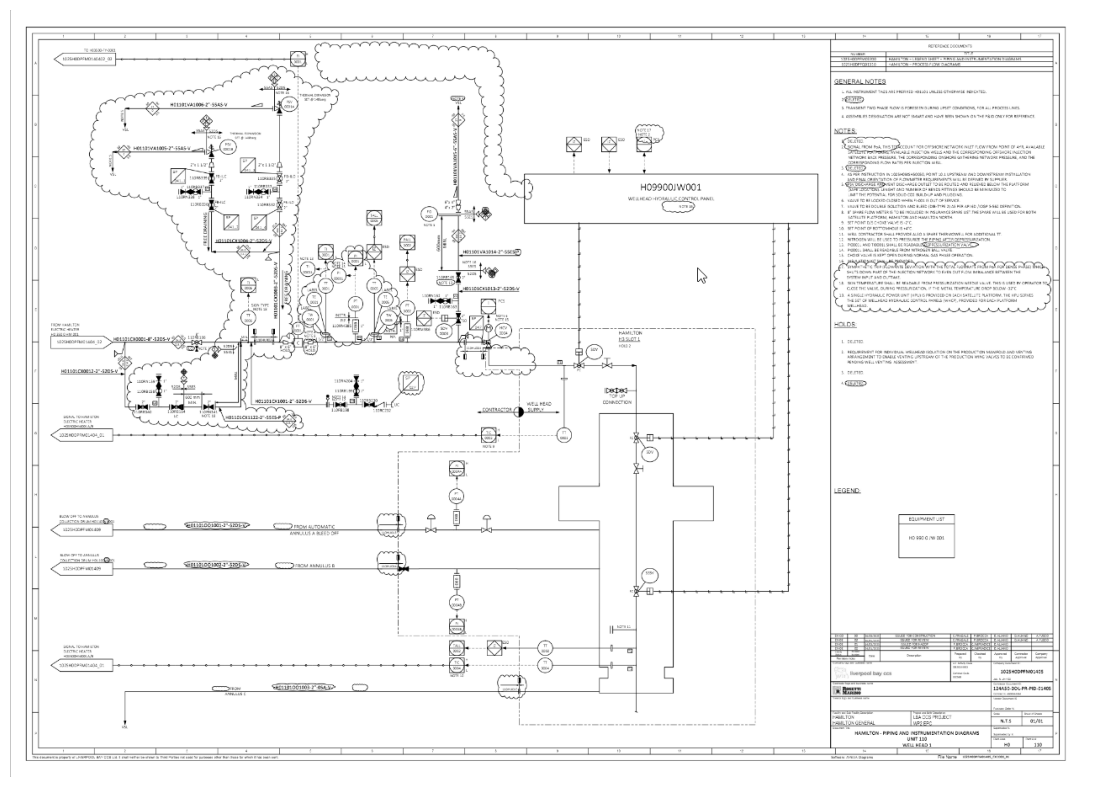

In [40]:
vis = cv2.cvtColor(pid_gray, cv2.COLOR_GRAY2RGB)

for x, y, w, h, score in final_detections:
    cv2.rectangle(vis, (x,y), (x+w, y+h), (255,0,0), 2)
    cv2.putText(
        vis, f"{score:.2f}", (x, y-5),
        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1
    )

plt.figure(figsize=(14,14))
plt.imshow(vis)
plt.axis("off")
plt.show()


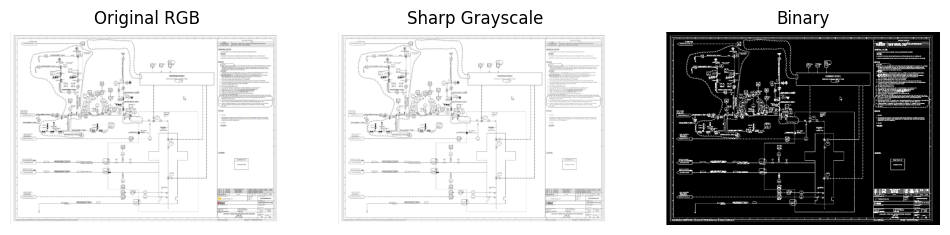

Total connected components: 442
✅ Candidate regions: 10


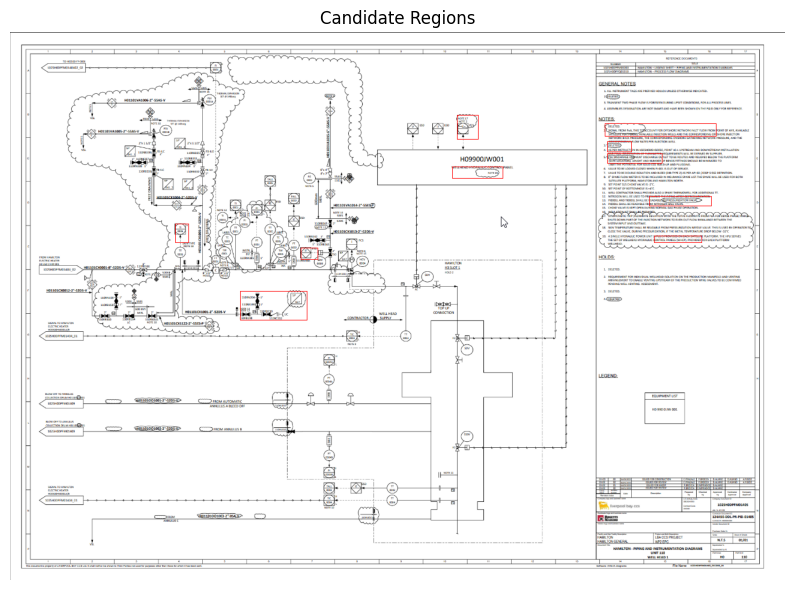

Raw detections: 0
✅ Final detections: 0


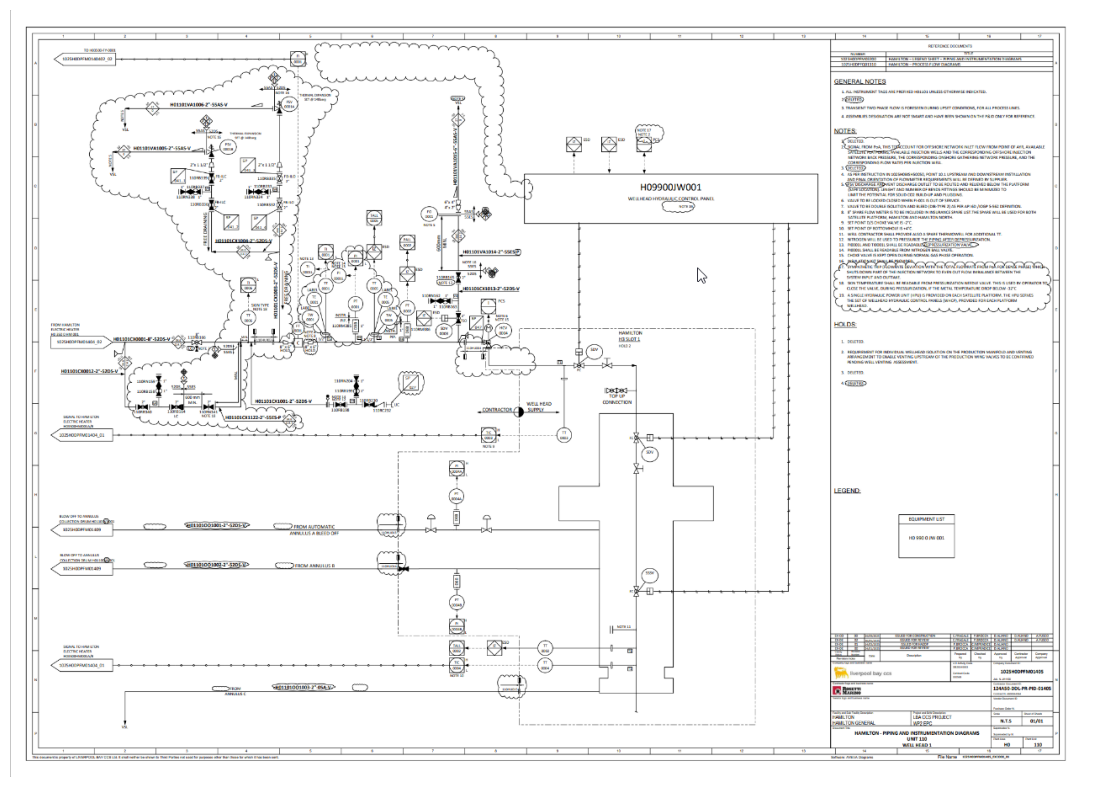

In [42]:
# =========================
# INSTALL (Colab)
# =========================
!pip install -q torch torchvision timm opencv-python pillow matplotlib numpy

# =========================
# IMPORTS
# =========================
import cv2
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD DINO MODEL
# =========================
model = timm.create_model(
    "vit_small_patch16_224.dino",
    pretrained=True
)
model.eval()
model.to(device)
model.reset_classifier(0)

# =========================
# TRANSFORM FOR DINO
# =========================
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# PATHS (CHANGE IF NEEDED)
# =========================
PID_PATH = "/content/pid_diagram.png"
LEGEND_PATH = "/content/legend_valve.jpg"

# =========================
# LOAD COLOR IMAGE (NO GRAYSCALE YET)
# =========================
pid_bgr = cv2.imread(PID_PATH)
assert pid_bgr is not None, "PID image not found"

pid_rgb = cv2.cvtColor(pid_bgr, cv2.COLOR_BGR2RGB)

# ✅ EDGE-PRESERVING GRAYSCALE (CRITICAL FIX)
pid_gray = np.max(pid_rgb, axis=2).astype(np.uint8)

# =========================
# ADAPTIVE BINARIZATION (PDF / CAD SAFE)
# =========================
bw = cv2.adaptiveThreshold(
    pid_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    5
)

# ✅ VERY LIGHT MORPHOLOGY (DO NOT OPEN)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
bw_clean = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel, iterations=1)

# =========================
# DEBUG VIEW (IMPORTANT)
# =========================
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(pid_rgb); plt.title("Original RGB"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(pid_gray, cmap="gray"); plt.title("Sharp Grayscale"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(bw_clean, cmap="gray"); plt.title("Binary"); plt.axis("off")
plt.show()

# =========================
# CONNECTED COMPONENTS (MUST BE > 0)
# =========================
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bw_clean, connectivity=8)
print("Total connected components:", num_labels)

candidates = []
for i in range(1, num_labels):
    x,y,w,h,area = stats[i]
    if (
        80 < area < 20000 and
        10 < w < 250 and
        10 < h < 250 and
        area/(w*h+1e-6) > 0.15
    ):
        candidates.append((x,y,w,h))

print("✅ Candidate regions:", len(candidates))

# =========================
# VISUALIZE CANDIDATES
# =========================
vis = pid_rgb.copy()
for x,y,w,h in candidates[:300]:
    cv2.rectangle(vis, (x,y), (x+w,y+h), (255,0,0), 1)

plt.figure(figsize=(10,10))
plt.imshow(vis); plt.axis("off"); plt.title("Candidate Regions")
plt.show()

# =========================
# DINO EMBEDDING FUNCTION
# =========================
def embed_pil(img):
    t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        e = model(t)
        e = e / e.norm(dim=-1, keepdim=True)
    return e.cpu()

# =========================
# LOAD LEGEND SYMBOL
# =========================
legend_img = Image.open(LEGEND_PATH).convert("RGB")

def legend_variants(img):
    out = []
    for a in [0,90,180,270]:
        out.append(img.rotate(a, expand=True))
        out.append(img.rotate(a, expand=True).transpose(Image.FLIP_LEFT_RIGHT))
    return out

legend_embs = [embed_pil(v) for v in legend_variants(legend_img)]
legend_proto = torch.mean(torch.stack(legend_embs), dim=0)

# =========================
# MATCH USING DINO
# =========================
detections = []

for x,y,w,h in candidates:
    crop = pid_gray[y:y+h, x:x+w]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_GRAY2RGB)
    emb = embed_pil(Image.fromarray(crop_rgb))
    sim = torch.cosine_similarity(emb, legend_proto).item()
    if sim > 0.90:
        detections.append((x,y,w,h,sim))

print("Raw detections:", len(detections))

# =========================
# SIMPLE NMS
# =========================
def nms(dets, dist=40):
    dets = sorted(dets, key=lambda x: x[4], reverse=True)
    out = []
    for d in dets:
        if all(abs(d[0]-o[0]) > dist or abs(d[1]-o[1]) > dist for o in out):
            out.append(d)
    return out

final = nms(detections)
print("✅ Final detections:", len(final))

# =========================
# FINAL RESULT
# =========================
vis = pid_rgb.copy()
for x,y,w,h,s in final:
    cv2.rectangle(vis, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.putText(vis, f"{s:.2f}", (x,y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1)

plt.figure(figsize=(14,14))
plt.imshow(vis); plt.axis("off")
plt.show()